In [1]:
import pandas as pd
import seaborn as sns
from glob import glob

# path = "/usr/share/fonts/opentype/linux-libertine/LinBiolinum_R.otf"
# fontManager.addfont(path)
sns.set_theme(style="ticks", font_scale=1.2)

frames = [pd.read_csv(data, names=[
    "NEAT", "_protocol", "chunk_k", "chunk_n", "chunk_m", "k", "n", "num_peer", "num_op", "op", "latency", "url", "id"
]) for data in glob('_data/entropy-5.txt')]
data = pd.concat(frames, ignore_index=True)
data = data[data['NEAT'] == 'NEAT']
data['latency'] = data['latency'].apply(pd.to_numeric)
data['num_peer'] = data['num_peer'].apply(pd.to_numeric)
data

,NEAT,_protocol,chunk_k,chunk_n,chunk_m,k,n,num_peer,num_op,op,latency,url,id
0,NEAT,ipfs,32,80,88,8,10,10000,1,put,30.142061,http://18.230.204.46:3000,0
1,NEAT,ipfs,32,80,88,8,10,10000,1,get,62.388943,http://16.162.254.75:3000,0
2,NEAT,ipfs,32,80,88,8,10,10000,1,put,26.055317,http://13.56.14.61:3000,0
3,NEAT,ipfs,32,80,88,8,10,10000,1,get,45.900604,http://52.53.130.28:3000,0
4,NEAT,ipfs,32,80,88,8,10,10000,1,put,29.219885,http://15.228.149.59:3000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,NEAT,ipfs,32,80,88,8,10,8000,1,get,34.565315,http://3.101.74.64:3000,0
347,NEAT,ipfs,32,80,88,8,10,8000,1,put,28.172401,http://15.228.149.59:3000,1
348,NEAT,ipfs,32,80,88,8,10,8000,1,get,43.124000,http://52.28.238.96:3000,0
349,NEAT,ipfs,32,80,88,8,10,8000,1,put,25.366936,http://13.56.227.238:3000,0


In [2]:
def outer_code(row):
    return f'({row["n"]}, {row["k"]})'
data['outer_code'] = data.apply(outer_code, axis=1)
def inner_code(row):
    return f'({row["chunk_n"]}, {row["chunk_k"]})'
data['inner_code'] = data.apply(inner_code, axis=1)
def op2(row):
    op = {"put": "Store", "get": "Retrieve"}[row["op"]]
    return op
data['op2'] = data.apply(op2, axis=1)
def protocol_op(row):
    p = {"ipfs": "Swarm", "entropy": "Entropy"}[row["_protocol"]]
    return f'{p} - {row["op2"]}'
data['protocol_op'] = data.apply(protocol_op, axis=1)
data

,NEAT,_protocol,chunk_k,chunk_n,chunk_m,k,n,num_peer,num_op,op,latency,url,id,outer_code,inner_code,op2,protocol_op
0,NEAT,ipfs,32,80,88,8,10,10000,1,put,30.142061,http://18.230.204.46:3000,0,"(10, 8)","(80, 32)",Store,Swarm - Store
1,NEAT,ipfs,32,80,88,8,10,10000,1,get,62.388943,http://16.162.254.75:3000,0,"(10, 8)","(80, 32)",Retrieve,Swarm - Retrieve
2,NEAT,ipfs,32,80,88,8,10,10000,1,put,26.055317,http://13.56.14.61:3000,0,"(10, 8)","(80, 32)",Store,Swarm - Store
3,NEAT,ipfs,32,80,88,8,10,10000,1,get,45.900604,http://52.53.130.28:3000,0,"(10, 8)","(80, 32)",Retrieve,Swarm - Retrieve
4,NEAT,ipfs,32,80,88,8,10,10000,1,put,29.219885,http://15.228.149.59:3000,0,"(10, 8)","(80, 32)",Store,Swarm - Store
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,NEAT,ipfs,32,80,88,8,10,8000,1,get,34.565315,http://3.101.74.64:3000,0,"(10, 8)","(80, 32)",Retrieve,Swarm - Retrieve
347,NEAT,ipfs,32,80,88,8,10,8000,1,put,28.172401,http://15.228.149.59:3000,1,"(10, 8)","(80, 32)",Store,Swarm - Store
348,NEAT,ipfs,32,80,88,8,10,8000,1,get,43.124000,http://52.28.238.96:3000,0,"(10, 8)","(80, 32)",Retrieve,Swarm - Retrieve
349,NEAT,ipfs,32,80,88,8,10,8000,1,put,25.366936,http://13.56.227.238:3000,0,"(10, 8)","(80, 32)",Store,Swarm - Store


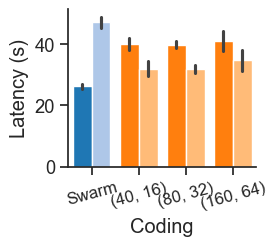

In [4]:
cell_data = data[data['outer_code'] == '(10, 8)']
def group(row):
    if row['_protocol'] == 'ipfs':
        return 'Swarm'
    else:
        return row['inner_code']
cell_data['group'] = cell_data.apply(group, axis=1)

f = sns.catplot(
    data=cell_data, kind="bar", 
    x="group", y="latency", hue="op2",
    order=['Swarm', '(40, 16)', '(80, 32)', '(160, 64)'],
    height=2.56, aspect=1.2)

# Manually set colors: Swarm = blue, Encoding = orange
swarm_colors = ['#1f77b4', '#aec7e8']  # Dark blue, Light blue
encoding_colors = ['#ff7f0e', '#ffbb78']  # Dark orange, Light orange

ax = f.axes[0, 0]
groups_order = ['Swarm', '(40, 16)', '(80, 32)', '(160, 64)']

bar_idx = 0
for hue_idx in range(2):  # 2 hue levels (Store, Retrieve)
    for group_idx in range(len(groups_order)):
        if bar_idx < len(ax.patches):
            if group_idx == 0:  # Swarm group
                ax.patches[bar_idx].set_facecolor(swarm_colors[hue_idx])
            else:  # Encoding groups
                ax.patches[bar_idx].set_facecolor(encoding_colors[hue_idx])
            bar_idx += 1

f.set(xlabel = "Coding")
f.set_xticklabels(fontsize='small')
f.set_xticklabels(rotation=15)
f._legend.remove()
f.set(ylabel="Latency (s)")
f.savefig('latency-inner.pdf')

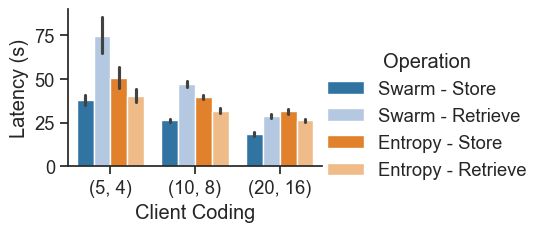

In [5]:
cell_data = data[data['inner_code'] == '(80, 32)']
f = sns.catplot(
    data=cell_data, kind="bar",
    x="outer_code", y="latency", hue="protocol_op",
    order=['(5, 4)', '(10, 8)', '(20, 16)'],
    palette=[*swarm_colors, *encoding_colors],
    height=2.56, aspect=1.5)
f.set(xlabel = "Client Coding")
f.set(ylabel="Latency (s)")
f._legend.set_title('Operation')
f.savefig('latency-outer.pdf')

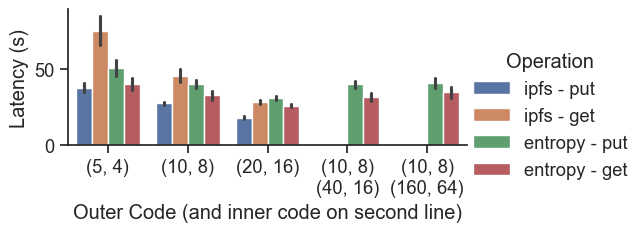

In [4]:
def group(row):
    if row['inner_code'] == '(80, 32)':
        return row['outer_code']
    else:
        return '(10, 8)\n' + row['inner_code']
data['group'] = data.apply(group, axis=1)
f = sns.catplot(data=data[(data["num_peer"] == 10000)], 
    kind="bar",
    x="group", y="latency", hue="op2",
    order=["(5, 4)", "(10, 8)", "(20, 16)", "(10, 8)\n(40, 16)", "(10, 8)\n(160, 64)"],
    height=2.56, aspect=2.)
f.set(xlabel = "Outer Code (and inner code on second line)")
f.set(ylabel="Latency (s)")
f._legend.set_title('Operation')
f.savefig('latency.pdf')

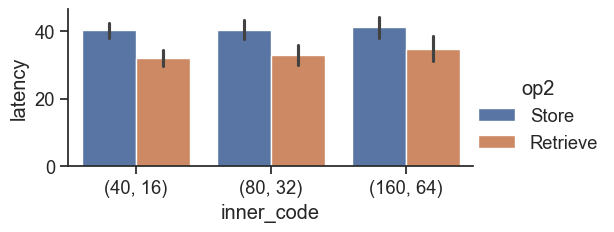

In [36]:
sns.catplot(data=data[(data["outer_code"] == "(10, 8)") & (data["num_peer"] == 10000) & (data["_protocol"] == "entropy")], 
    kind="bar",
    x="inner_code", y="latency", hue="op2",
    order=["(40, 16)", "(80, 32)", "(160, 64)"],
    height=2.56, aspect=2.)

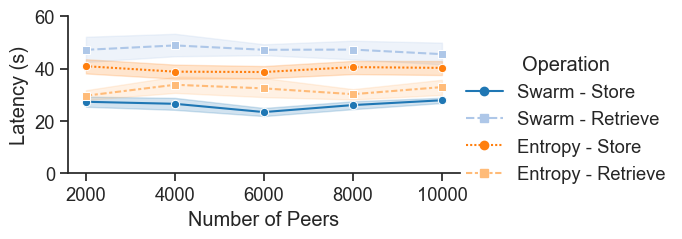

In [40]:
f = sns.relplot(data=data[(data["outer_code"] == "(10, 8)") & (data["inner_code"] == "(80, 32)")],
    kind="line",
    x="num_peer", y="latency", hue="protocol_op",
    palette=[*swarm_colors, *encoding_colors], markers=["o", "s", "o", "s"], style="protocol_op",
    height=2.56, aspect=2.)
f.set(xlabel = "Number of Peers")
f.set(ylabel="Latency (s)")
f._legend.set_title('Operation')
f.set(ylim=(0, 60))
f.savefig('peer.pdf')

In [ ]:
frames = [pd.read_csv(data, names=[
    "NEAT", "num_replica", "faulty_portion", "num_alive",
]) for data in glob('entropy-ipfs-loss.txt')]
data = pd.concat(frames, ignore_index=True)
data = data[data['NEAT'] == 'NEAT']
data['num_replica'] = data['num_replica'].apply(pd.to_numeric)
data['faulty_portion'] = data['faulty_portion'].apply(pd.to_numeric)
data['num_alive'] = data['num_alive'].apply(pd.to_numeric)
data

In [ ]:
sns.relplot(data=data,
    kind="line",
    x="faulty_portion", y="num_alive", hue="num_replica",
    height=2.56, aspect=2.)

In [ ]:
frames = [pd.read_csv(data, names=[
    "NEAT", "_protocol", "chunk_k", "chunk_n", "chunk_m", "k", "n", "num_peer", "num_op", "op", "latency", "url", "id"
]) for data in glob('entropy-1.txt')]
data = pd.concat(frames, ignore_index=True)
data = data[data['NEAT'] == 'NEAT']
data['latency'] = data['latency'].apply(pd.to_numeric)
data

In [ ]:
f = sns.relplot(data=data,
    kind="line",
    x="num_op", y="latency", hue="op",
    height=2.56, aspect=2.)